<a href="https://colab.research.google.com/github/RichardMorris/TRUR2290-25-26/blob/main/sinusoidal_regression_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sinusoidal Regression Example

### Download Data set

In [ ]:
!curl -L -o ./sinusoidal-regression.zip https://www.kaggle.com/api/v1/datasets/download/kevinahg/temperature-across-day
!unzip -o ./sinusoidal-regression.zip -d .

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  1657  100  1657    0     0   2236      0 --:--:-- --:--:-- --:--:--  2236
Archive:  ./sinusoidal-regression.zip
  inflating: ./temperature_across_day.csv  


### Import Packages

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
import numpy as np
import csv
import pandas

import scipy

from math import sin, cos

### Load Data

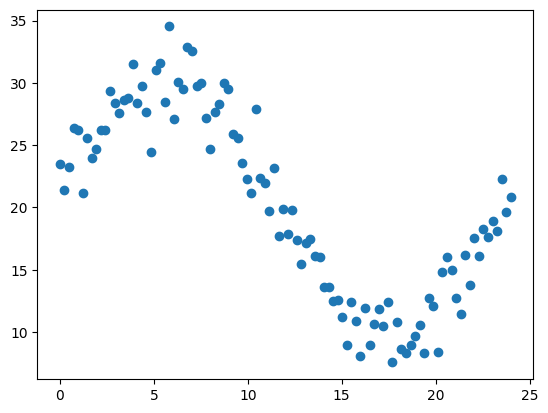

In [ ]:
with open("./temperature_across_day.csv", mode="r") as csvFile:
  reader = csv.reader(csvFile)
  data = []
  skipHeader = True
  for row in reader:
    if skipHeader:
      skipHeader = False
      continue
    data.append((float(row[0]),float(row[1])))

plt.scatter([d[0] for d in data],[d[1] for d in data])

In [ ]:
learningRate = 0.005

amplitude = 10
frequency = 1
phase_shift = 2
vertical_shift = 10

In [ ]:
def MeanSquareError():
  TotalSquareError = 0.0
  for point in data:
    x = point[0]
    y = point[1]
    TotalSquareError += ((amplitude * sin(frequency * x + phase_shift) + vertical_shift) - y)**2
  return TotalSquareError / len(data)

MeanSquareError()

214.56556183645992

In [ ]:
def UpdateAmplitude():
  Total = 0.0
  for point in data:
    x = point[0]
    y = point[1]
    error = y - (amplitude * sin(frequency * x + phase_shift) + vertical_shift)
    Total +=  error * sin(frequency * x + phase_shift)
  return -2 * Total / len(data)

def UpdateFrequency():
  Total = 0.0
  for point in data:
    x = point[0]
    y = point[1]
    error = y - (amplitude * sin(frequency * x + phase_shift) + vertical_shift)
    Total +=  error * amplitude * x * cos(frequency * x + phase_shift)
  return -2 * Total / len(data)

def UpdatePhaseShift():
  Total = 0.0
  for point in data:
    x = point[0]
    y = point[1]
    error = y - (amplitude * sin(frequency * x + phase_shift) + vertical_shift)
    Total +=  error * amplitude * cos(frequency * x + phase_shift)
  return -2 * Total / len(data)

def UpdateVerticalShift():
  Total = 0.0
  for point in data:
    x = point[0]
    y = point[1]
    error = y - (amplitude * sin(frequency * x + phase_shift) + vertical_shift)
    Total +=  error
  return -2 * Total / len(data)

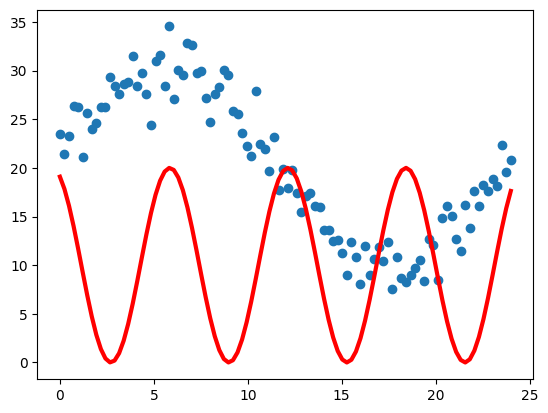

In [ ]:
def Line(x):
  return amplitude * sin(frequency * x + phase_shift) + vertical_shift

plt.plot([d[0] for d in data],[Line(float(d[0])) for d in data],c="red",linewidth='3')
plt.scatter([d[0] for d in data],[d[1] for d in data])

In [ ]:
for i in range(100000):
  _a = UpdateAmplitude()
  _f = UpdateFrequency()
  _p = UpdatePhaseShift()
  vertical_shift -= learningRate * UpdateVerticalShift()
  amplitude -= learningRate * _a
  frequency -= learningRate * _f
  phase_shift -= learningRate * _p

MeanSquareError()

55.67971047188716

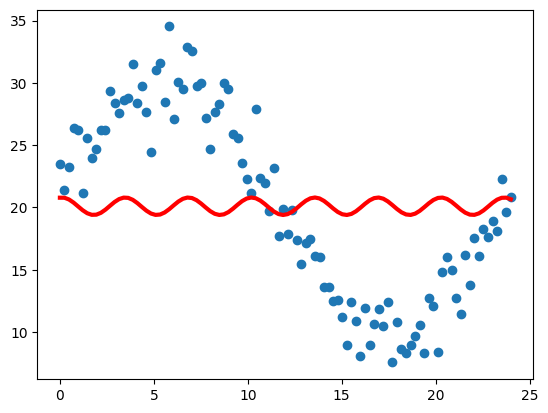

In [ ]:
plt.plot([d[0] for d in data],[Line(float(d[0])) for d in data],c="red",linewidth='3')
plt.scatter([d[0] for d in data],[d[1] for d in data])